# Player Reception vs. Critic Score: Steam Game Divergence Analysis

This notebook uses the 5 cleaned CSVs under `Cleaned_Data/` and performs analytics to answer one question:

> Where do Steam player ratings (`review_score` / positive ratio) and critic ratings (`metacritic_score`) systematically disagree — across titles, genres, publishers, price tiers, and years?

Table of contents:

0. **Setup**
1. **Metric construction & distributions**
2. **Consistency & correlation**
3. **Four-quadrant split** — Both Loved / Player-Favored / Critic-Favored / Both Disliked
4. **Most under-rated / over-rated title lists**
5. **Slice by genre**
6. **Slice by category & tag**
7. **Slice by publisher / developer**
8. **Slice by price / free vs paid / owners range**
9. **Trend by release year**

## Section 0 — Setup

Import dependencies, define CONFIG, load the 5 cleaned CSVs and merge them to build the core analysis sample.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.unicode_minus"] = False

CONFIG = {
    "min_total_reviews": 10,       # minimum player-review count to suppress small-sample noise
    "player_love_threshold": 0.80, # positive ratio >= 80%  -> "players love it"
    "critic_love_threshold": 75,   # metacritic    >= 75    -> "critics love it"
    "min_games_per_genre": 20,     # minimum games per genre for the genre aggregation
    "min_games_per_category": 20,
    "min_games_per_publisher": 5,
    "min_games_per_developer": 5,
    "top_n": 15,
}

reviews = pd.read_csv("Cleaned_Data/reviews_clean.csv")
games = pd.read_csv("Cleaned_Data/games_clean.csv")
genres = pd.read_csv("Cleaned_Data/genres_clean.csv")
tags = pd.read_csv("Cleaned_Data/tags_clean.csv")
categories = pd.read_csv("Cleaned_Data/categories_clean.csv")

OWNERS_ORDER = [
    "0 .. 20,000",
    "20,000 .. 50,000",
    "50,000 .. 100,000",
    "100,000 .. 200,000",
    "200,000 .. 500,000",
    "500,000 .. 1,000,000",
    "1,000,000 .. 2,000,000",
    "2,000,000 .. 5,000,000",
    "5,000,000 .. 10,000,000",
    "10,000,000 .. 20,000,000",
    "20,000,000 .. 50,000,000",
    "50,000,000 .. 100,000,000",
    "100,000,000 .. 200,000,000",
]

games = games.copy()
games["release_date"] = pd.to_datetime(games["release_date"], errors="coerce")
games["release_year"] = games["release_date"].dt.year
games["owners_range"] = pd.Categorical(
    games["owners_range"], categories=[c for c in OWNERS_ORDER if c in set(games["owners_range"].dropna().unique())], ordered=True,)
games["is_free"] = games["is_free"].astype("Int64")

In [2]:
df = reviews.merge(games, on="app_id", how="left")

n_raw = len(df)
n_has_metacritic = df["metacritic_score"].notna().sum()

core = df[df["metacritic_score"].notna() & (df["total"] >= CONFIG["min_total_reviews"])].copy()

report = pd.DataFrame(
    {
        "stage": [
            "Raw reviews rows",
            "Has metacritic_score",
            f"And total >= {CONFIG['min_total_reviews']} (core analysis sample)",
        ],
        "rows": [n_raw, int(n_has_metacritic), len(core)],
    }
)
report["pct_of_raw"] = (report["rows"] / n_raw * 100).round(2).astype(str) + "%"
report

,stage,rows,pct_of_raw
0,Raw reviews rows,140082,100.0%
1,Has metacritic_score,4745,3.39%
2,And total >= 10 (core analysis sample),4155,2.97%


## Section 1 — Metric construction & distributions

To make the two ratings comparable, we put both the player side and the critic side on the same 0-100 scale:

- `player_ratio = positive / total` (finest-grained positive ratio, 0-1)
- `player_ratio_100 = player_ratio * 100` (rescaled to 0-100)
- `player_norm = review_score / 9 * 100` (Steam's aggregate score normalised)
- `critic_norm = metacritic_score` (already 0-100)

Divergence definition: **positive = players love it more than critics; negative = critics love it more than players**

- `divergence_ratio = player_ratio_100 - critic_norm` (primary metric, based on raw positive ratio)
- `divergence_steam = player_norm - critic_norm` (secondary metric, based on Steam's aggregate tier)

In [3]:
core["player_ratio"]     = core["positive"] / core["total"]
core["player_ratio_100"] = core["player_ratio"] * 100
core["player_norm"]      = core["review_score"] / 9 * 100
core["critic_norm"]      = core["metacritic_score"].astype(float)
core["divergence_ratio"] = core["player_ratio_100"] - core["critic_norm"]
core["divergence_steam"] = core["player_norm"]      - core["critic_norm"]

core[[
    "player_ratio_100", "player_norm", "critic_norm",
    "divergence_ratio", "divergence_steam",
]].describe().round(2)

,player_ratio_100,player_norm,critic_norm,divergence_ratio,divergence_steam
count,4155.00,4155.00,4155.00,4155.00,4155.00
mean,80.50,78.25,73.57,6.93,4.68
std,14.11,15.34,10.30,11.47,12.93
min,10.00,11.11,20.00,-63.26,-53.78
25%,73.30,66.67,68.00,1.02,-4.33
50%,83.97,88.89,75.00,8.16,6.89
75%,91.26,88.89,81.00,14.05,13.89
max,100.00,100.00,97.00,47.85,53.89


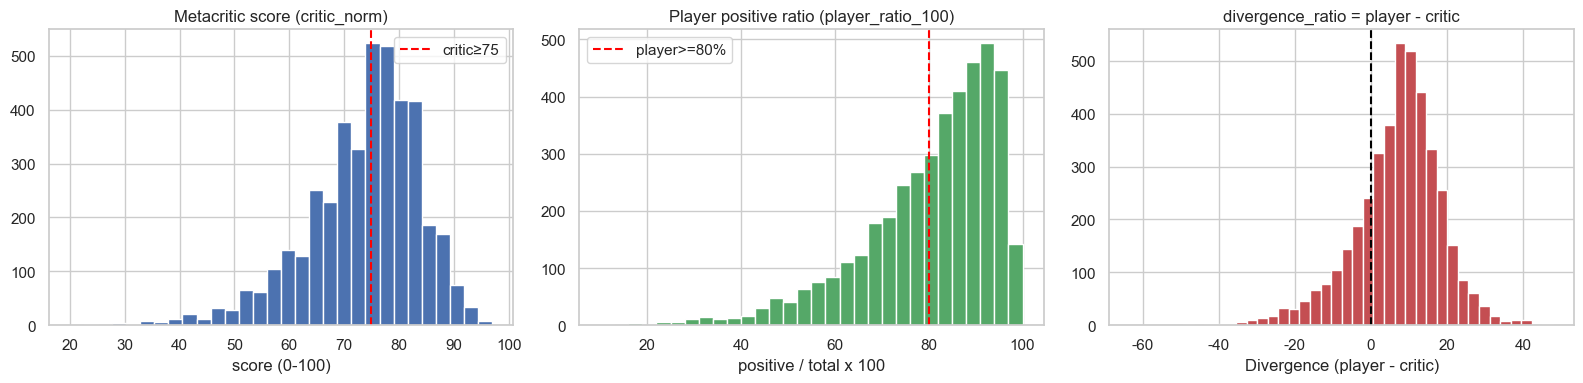

review_score_description
Very Positive              2090
Mostly Positive             788
Mixed                       767
Overwhelmingly Positive     311
Positive                    134
Mostly Negative              58
Overwhelmingly Negative       4
Very Negative                 2
Negative                      1
Name: count, dtype: int64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(core["critic_norm"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].axvline(CONFIG["critic_love_threshold"], color="red", linestyle="--", label=f"critic≥{CONFIG['critic_love_threshold']}")
axes[0].set_title("Metacritic score (critic_norm)")
axes[0].set_xlabel("score (0-100)")
axes[0].legend()

axes[1].hist(core["player_ratio_100"], bins=30, color="#55A868", edgecolor="white")
axes[1].axvline(CONFIG["player_love_threshold"] * 100, color="red", linestyle="--", label=f"player>={int(CONFIG['player_love_threshold']*100)}%")
axes[1].set_title("Player positive ratio (player_ratio_100)")
axes[1].set_xlabel("positive / total x 100")
axes[1].legend()

axes[2].hist(core["divergence_ratio"], bins=40, color="#C44E52", edgecolor="white")
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set_title("divergence_ratio = player - critic")
axes[2].set_xlabel("Divergence (player - critic)")

plt.tight_layout()
plt.show()

desc_counts = core["review_score_description"].value_counts()
print(desc_counts)

The score distribution on display in histogram 1 shows a dotted red line around the 75/100 mark, signifying the average Metacritic score across 4,155 games. The average critic score may seem low, but it appears that critics tend to avoid holding extreme positions with their reviews. Compare this to histogram 2 and we can see a clear and stark difference between how critics review games versus how players review games.

In histogram 2, there is a clear left-skew leaning towards games that are over 80% positive. Clearly, there aren't many negative reviews available to us. An assumption can be made about this: the average consumer is more likely to review a game that they deem as "positive" than a game that they perceive as "negative". Players may only feel inclined to review games that they enjoy over games that they may have issues with.

Histogram 3 shows us that the divergence ratio is slightly above the baseline of 0 that we've established. There is some credibility to be had in concluding that players are generally more positive and more likely to give a good review for a video game than the analysts over at Metacritic.

## Section 2 — Consistency & correlation

How aligned are players and critics overall? We use a scatter plot with a 45° reference line and a binned-mean curve.

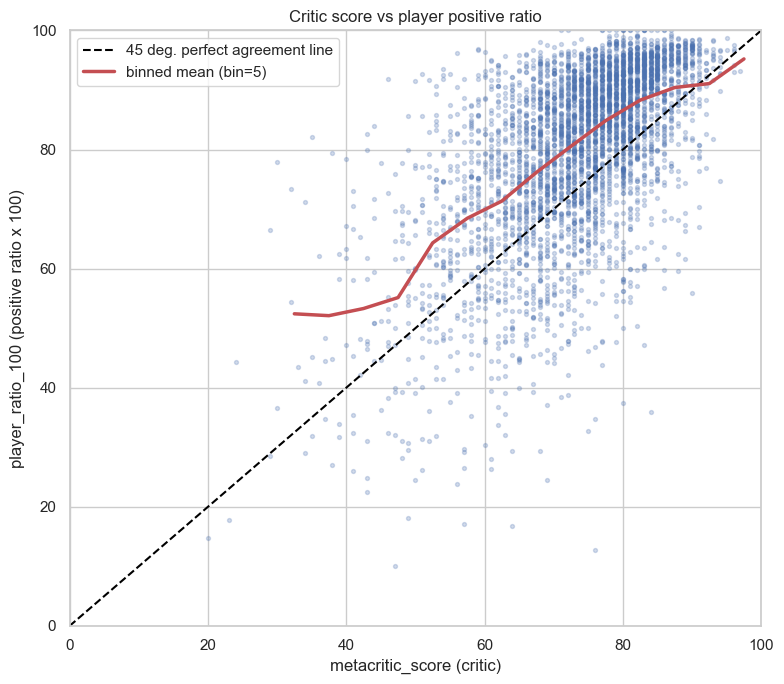

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    core["critic_norm"], core["player_ratio_100"],
    s=8, alpha=0.25, color="#4C72B0",
)
ax.plot([0, 100], [0, 100], color="black", linestyle="--", label="45 deg. perfect agreement line")

bins = np.arange(0, 101, 5)
core["_critic_bin"] = pd.cut(core["critic_norm"], bins=bins, include_lowest=True)
binned = core.groupby("_critic_bin", observed=True)["player_ratio_100"].agg(["mean", "count"]).reset_index()
binned["critic_mid"] = binned["_critic_bin"].apply(lambda x: (x.left + x.right) / 2 if pd.notna(x) else np.nan)
binned = binned[binned["count"] >= 5]

ax.plot(binned["critic_mid"], binned["mean"], color="#C44E52", linewidth=2.5, label="binned mean (bin=5)")

ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_xlabel("metacritic_score (critic)")
ax.set_ylabel("player_ratio_100 (positive ratio x 100)")
ax.set_title("Critic score vs player positive ratio")
ax.legend()
plt.tight_layout()
plt.show()

core.drop(columns=["_critic_bin"], inplace=True)

This scatter plot depicts the Metacritic score vs the player positivity ratio. The dashed diagonal line is meant to be the medium where there is a perfect agreement between the two parties review scores. The red binned-mean line is meant to track the players ratings and signifies what we established in our earlier histograms (that players are typically more positive than critics when reviewing games). We can notice that there is a dip in the binned-mean around the 90 mark on the X-axis. This could be due to critically acclaimed games garnering more attention from the public, and therefore more scrutiny/backlash as well. We can see that there is quite the contrast with player ratings for lower-rated games vs higher-rated games.

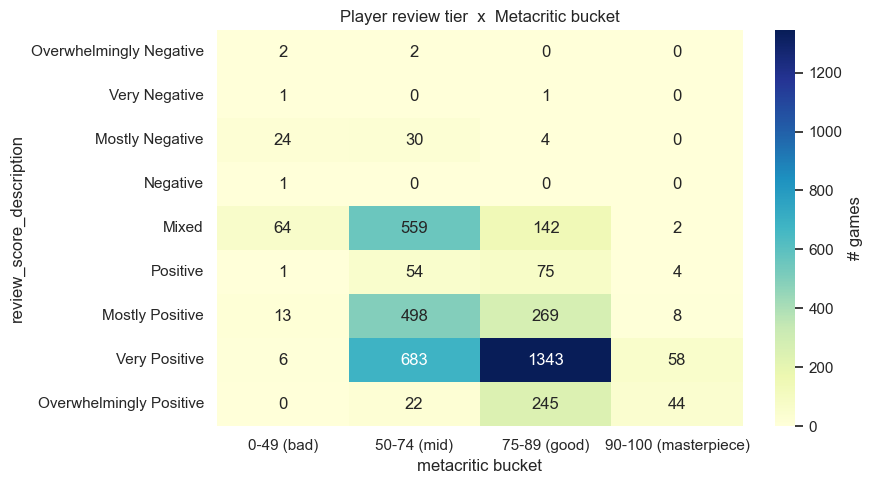

In [6]:
metacritic_bins = [0, 49, 74, 89, 100]
metacritic_labels = ["0-49 (bad)", "50-74 (mid)", "75-89 (good)", "90-100 (masterpiece)"]
core["_critic_bucket"] = pd.cut(
    core["critic_norm"], bins=metacritic_bins, labels=metacritic_labels, include_lowest=True,
)

desc_order = [
    "Overwhelmingly Negative", "Very Negative", "Mostly Negative", "Negative",
    "Mixed",
    "Positive", "Mostly Positive", "Very Positive", "Overwhelmingly Positive",
]
desc_present = [d for d in desc_order if d in core["review_score_description"].unique()]

cross = pd.crosstab(
    core["review_score_description"].astype(pd.CategoricalDtype(desc_present, ordered=True)),
    core["_critic_bucket"],
).reindex(index=desc_present)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(cross, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={"label": "# games"}, ax=ax)
ax.set_title("Player review tier  x  Metacritic bucket")
ax.set_xlabel("metacritic bucket")
ax.set_ylabel("review_score_description")
plt.tight_layout()
plt.show()

This heatmap cross-tabulates player reviews with metacritic scores and highlights the overlaps and dichotomies between the two. The area where the weights seem to concentrate the most would be where "Very Positive" player reviews and "75-89(good) Metacritic reviews meet at 1343 games. This is where both parties seem to have a consensus agreement on the quality of the video game.
There are very few games that were labeled as "mostly negative" by players but were rated as "good" by Metacritic. Same can be said for games that were deemed "overwhelmingly positive" and "masterpieces" by both parties. These are rarities in the grand scheme of the project scope, and it confirms that there is a lack of vast consensus agreement in this dataset.

## Section 3 — Four-quadrant split

Using the thresholds `player_ratio >= 80%` and `metacritic >= 75`, we assign each title in the core sample to one of four quadrants:

| Quadrant | Players | Critics | Typical interpretation |
| --- | --- | --- | --- |
| Q1  Both Loved       | love | love | Universally acclaimed |
| Q2  Player-Favored   | love | dis  | Hidden gem / underrated |
| Q3  Critic-Favored   | dis  | love | Inverted reception / overrated |
| Q4  Both Disliked    | dis  | dis  | Universally disliked |

Thresholds are centralised in the `CONFIG` block at the top.

In [7]:
p_thr = CONFIG["player_love_threshold"]
c_thr = CONFIG["critic_love_threshold"]

def assign_quadrant(row):
    p_ok = row["player_ratio"] >= p_thr
    c_ok = row["critic_norm"]  >= c_thr
    if p_ok and c_ok:       return "Q1 Both Loved"
    if p_ok and not c_ok:   return "Q2 Player-Favored"
    if not p_ok and c_ok:   return "Q3 Critic-Favored"
    return "Q4 Both Disliked"

core["quadrant"] = core.apply(assign_quadrant, axis=1)

quad_summary = (
    core["quadrant"]
    .value_counts()
    .reindex(["Q1 Both Loved", "Q2 Player-Favored", "Q3 Critic-Favored", "Q4 Both Disliked"])
    .rename_axis("quadrant")
    .reset_index(name="count")
)
quad_summary["pct"] = (quad_summary["count"] / quad_summary["count"].sum() * 100).round(2).astype(str) + "%"
quad_summary

,quadrant,count,pct
0,Q1 Both Loved,1769,42.58%
1,Q2 Player-Favored,766,18.44%
2,Q3 Critic-Favored,426,10.25%
3,Q4 Both Disliked,1194,28.74%


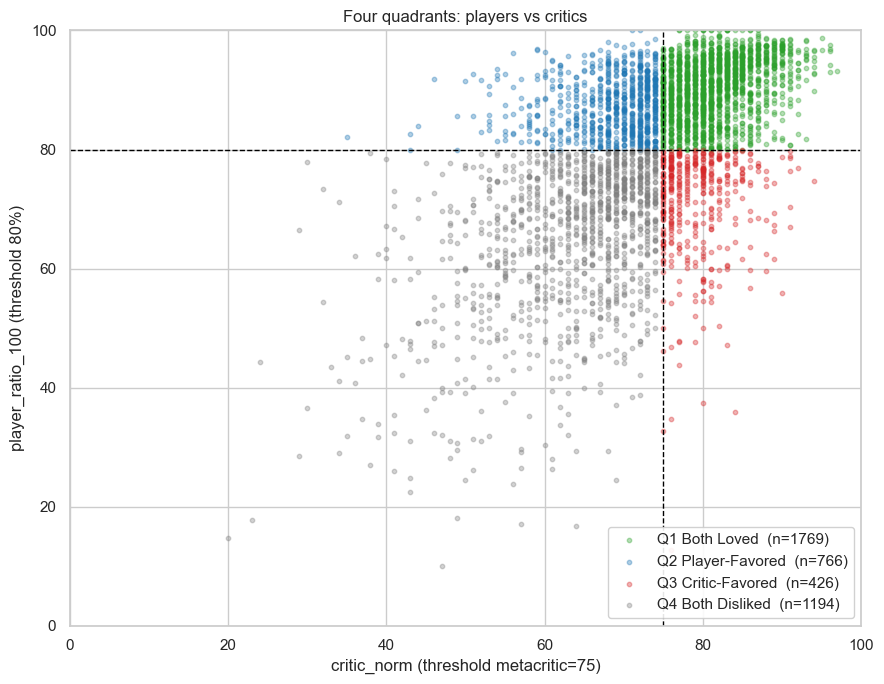

In [8]:
quad_palette = {
    "Q1 Both Loved":       "#2ca02c",
    "Q2 Player-Favored":   "#1f77b4",
    "Q3 Critic-Favored":   "#d62728",
    "Q4 Both Disliked":    "#7f7f7f",
}

fig, ax = plt.subplots(figsize=(9, 7))
for q, color in quad_palette.items():
    sub = core[core["quadrant"] == q]
    ax.scatter(sub["critic_norm"], sub["player_ratio_100"],
               s=10, alpha=0.35, color=color, label=f"{q}  (n={len(sub)})")

ax.axvline(c_thr,       color="black", linestyle="--", linewidth=1)
ax.axhline(p_thr * 100, color="black", linestyle="--", linewidth=1)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_xlabel(f"critic_norm (threshold metacritic={c_thr})")
ax.set_ylabel(f"player_ratio_100 (threshold {int(p_thr*100)}%)")
ax.set_title("Four quadrants: players vs critics")
ax.legend(loc="lower right", framealpha=0.9)
plt.tight_layout()
plt.show()

## Section 4 — Most under-rated / over-rated title lists

Sorting by `divergence_ratio`, we pick the biggest positive-divergence titles (hidden gems) and biggest negative-divergence titles (critic darlings).

To avoid titles making the list purely because of tiny review counts, we additionally require `total >= 200`.

In [9]:
list_cols = [
    "app_id", "name", "developer", "publisher",
    "release_year", "price", "owners_range",
    "total", "player_ratio_100", "critic_norm",
    "divergence_ratio", "quadrant",
]

ranked = core[core["total"] >= 200].copy()

most_underrated = (
    ranked.sort_values("divergence_ratio", ascending=False)
          .head(CONFIG["top_n"])[list_cols]
          .reset_index(drop=True)
)
most_overrated = (
    ranked.sort_values("divergence_ratio", ascending=True)
          .head(CONFIG["top_n"])[list_cols]
          .reset_index(drop=True)
)

def _fmt(df_):
    out = df_.copy()
    out["player_ratio_100"] = out["player_ratio_100"].round(1)
    out["critic_norm"]      = out["critic_norm"].round(0).astype(int)
    out["divergence_ratio"] = out["divergence_ratio"].round(1)
    return out

print(f"[Most under-rated Top {CONFIG['top_n']}] players love it more than critics (positive divergence)")
_fmt(most_underrated)

[Most under-rated Top 15] players love it more than critics (positive divergence)


,app_id,name,developer,publisher,release_year,price,owners_range,total,player_ratio_100,critic_norm,divergence_ratio,quadrant
0,375950,Viridi,"Zoe Vartanian, Badru, Isa Hutchinson, Michael ...",Ice Water Games,2015.0,0.00,"500,000 .. 1,000,000",9145.0,91.8,46,45.8,Q2 Player-Favored
1,388090,Five Nights at Freddy's 4,Scott Cawthon,Scott Cawthon,2015.0,7.99,"500,000 .. 1,000,000",14199.0,92.7,51,41.7,Q2 Player-Favored
2,448370,IS Defense,Destructive Creations,Destructive Creations,2016.0,5.99,"50,000 .. 100,000",1570.0,91.5,50,41.5,Q2 Player-Favored
3,46770,Making History II: The War of the World,Muzzy Lane Software,Factus Games,2010.0,14.99,"50,000 .. 100,000",374.0,79.4,38,41.4,Q4 Both Disliked
4,262190,Zombeer,"Moonbite Games, PadaOne Games",New Gravity Laws,2015.0,4.99,"50,000 .. 100,000",281.0,73.3,32,41.3,Q4 Both Disliked
5,91900,Post Apocalyptic Mayhem,Steel Monkeys,Next Dimension Game Adventures Ltd.,2011.0,9.99,"200,000 .. 500,000",1495.0,84.0,44,40.0,Q2 Player-Favored
6,341940,Hatred,Destructive Creations,Destructive Creations,2015.0,5.99,"500,000 .. 1,000,000",19586.0,82.6,43,39.6,Q2 Player-Favored
7,377080,Hatoful Boyfriend: Holiday Star,Mediatonic,Epic Games,2015.0,9.99,"20,000 .. 50,000",542.0,93.5,54,39.5,Q2 Player-Favored
8,485870,Super Duper Party Pooper,K Bros Games,K Bros Games,2016.0,0.99,"100,000 .. 200,000",445.0,78.4,40,38.4,Q4 Both Disliked
9,401680,POSTAL Redux,Running With Scissors,Running With Scissors,2016.0,8.99,"20,000 .. 50,000",6116.0,91.9,54,37.9,Q2 Player-Favored


In [10]:
print(f"[Most over-rated Top {CONFIG['top_n']}] critics love it more than players (negative divergence)")
_fmt(most_overrated)

[Most over-rated Top 15] critics love it more than players (negative divergence)


,app_id,name,developer,publisher,release_year,price,owners_range,total,player_ratio_100,critic_norm,divergence_ratio,quadrant
0,373960,Audiosurf 2 Demo,Dylan Fitterer,Dylan Fitterer,2015.0,0.00,"0 .. 20,000",259.0,12.7,76,-63.3,Q3 Critic-Favored
1,47700,Command & Conquer™ 4 Tiberian Twilight,EA Los Angeles,Electronic Arts,NaN,19.88,"200,000 .. 500,000",4089.0,16.8,64,-47.2,Q4 Both Disliked
2,283350,Eurofighter Typhoon,Rage Software,Funbox Media Ltd,2014.0,2.99,"20,000 .. 50,000",224.0,24.6,69,-44.4,Q4 Both Disliked
3,13580,Tom Clancy's Splinter Cell Double Agent®,Ubisoft Montreal,Ubisoft,2009.0,2.49,"200,000 .. 500,000",1588.0,37.5,80,-42.5,Q3 Critic-Favored
4,741820,Prey: Typhon Hunter,Arkane Studios,Bethesda Softworks,2018.0,9.99,"50,000 .. 100,000",792.0,32.7,75,-42.3,Q3 Critic-Favored
5,201490,Airline Tycoon 2,b-Alive,Kalypso Media Digital,2011.0,9.99,"50,000 .. 100,000",561.0,17.1,57,-39.9,Q4 Both Disliked
6,289820,Dracula 2: The Last Sanctuary,Microids,Microids,2014.0,4.99,"20,000 .. 50,000",258.0,29.5,68,-38.5,Q4 Both Disliked
7,214150,Galactic Civilizations® I: Ultimate Edition,Stardock Entertainment,Stardock Entertainment,2012.0,9.99,"200,000 .. 500,000",271.0,47.2,83,-35.8,Q3 Critic-Favored
8,34920,Razor2: Hidden Skies,Invent4 Entertainment,Strategy First,2010.0,7.99,"50,000 .. 100,000",228.0,26.3,61,-34.7,Q4 Both Disliked
9,8880,Freedom Force,Irrational Games,2K,2009.0,4.99,"100,000 .. 200,000",509.0,56.0,90,-34.0,Q3 Critic-Favored


## Section 5 — Slice by genre

A game can carry multiple genres, so one title contributes to every genre it belongs to (standard practice for Steam data).
We only keep genres with at least `min_games_per_genre` games in the core sample.

In [11]:
def slice_by_long_table(long_df, key_col, min_games):
    """Join core with a long table on app_id, then aggregate divergence by key_col."""
    joined = long_df.merge(
        core[["app_id", "divergence_ratio", "quadrant"]],
        on="app_id", how="inner",
    )
    agg = (
        joined.groupby(key_col)
              .agg(n_games=("app_id", "nunique"),
                   mean_div=("divergence_ratio", "mean"),
                   median_div=("divergence_ratio", "median"))
              .reset_index()
    )
    quad_pct = (
        joined.groupby([key_col, "quadrant"])["app_id"].nunique()
              .unstack("quadrant").fillna(0)
    )
    quad_pct = quad_pct.div(quad_pct.sum(axis=1), axis=0) * 100
    quad_pct = quad_pct.add_prefix("pct_").reset_index()

    out = agg.merge(quad_pct, on=key_col)
    out = out[out["n_games"] >= min_games].copy()
    out["mean_div"]   = out["mean_div"].round(2)
    out["median_div"] = out["median_div"].round(2)
    for c in [c for c in out.columns if c.startswith("pct_")]:
        out[c] = out[c].round(1)
    return out.sort_values("mean_div", ascending=False).reset_index(drop=True)


q2_ids = set(core.loc[core["quadrant"] == "Q2 Player-Favored", "app_id"])
q3_ids = set(core.loc[core["quadrant"] == "Q3 Critic-Favored", "app_id"])

def plot_quadrant_signature(long_df, key_col, q2_ids, q3_ids,
                            min_support=10, n_each=15, label=None):
    """Compare how often each value of `long_df[key_col]` appears in Q2 vs Q3 games.

    Produces two horizontal bar charts:
      - left  (blue): values most over-represented in Player-Favored (Q2) games
      - right (red):  values most over-represented in Critic-Favored (Q3) games

    Returns the full comparison DataFrame so the caller can inspect the numbers.
    """
    def _freq(app_ids):
        sub = long_df[long_df["app_id"].isin(app_ids)]
        counts = sub[key_col].value_counts()
        return (counts / len(app_ids) * 100).rename("pct")

    q2f = _freq(q2_ids)
    q3f = _freq(q3_ids)

    cmp = pd.concat([q2f, q3f], axis=1, keys=["q2_pct", "q3_pct"]).fillna(0)
    cmp["support"] = (cmp["q2_pct"] / 100 * len(q2_ids)) + (cmp["q3_pct"] / 100 * len(q3_ids))
    cmp = cmp[cmp["support"] >= min_support]
    cmp["diff"] = cmp["q2_pct"] - cmp["q3_pct"]

    top_q2 = cmp.nlargest(n_each, "diff")
    top_q3 = cmp.nsmallest(n_each, "diff")

    lbl = label or key_col
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

    axes[0].barh(top_q2.index[::-1], top_q2["diff"][::-1], color="#1f77b4")
    axes[0].set_title(f"Player-Favored (Q2, n={len(q2_ids)}) signature {lbl}s\n(Q2 freq - Q3 freq, pp)")
    axes[0].set_xlabel("Delta (pp)")

    axes[1].barh(top_q3.index[::-1], -top_q3["diff"][::-1], color="#d62728")
    axes[1].set_title(f"Critic-Favored (Q3, n={len(q3_ids)}) signature {lbl}s\n(Q3 freq - Q2 freq, pp)")
    axes[1].set_xlabel("Delta (pp)")

    plt.tight_layout()
    plt.show()
    return cmp.sort_values("diff", ascending=False)


genre_stats = slice_by_long_table(genres, "genre", CONFIG["min_games_per_genre"])
print(f"Genre slice (n_games >= {CONFIG['min_games_per_genre']}): {len(genre_stats)} genres kept")
genre_stats

Genre slice (n_games >= 20): 11 genres kept


,genre,n_games,mean_div,median_div,pct_Q1 Both Loved,pct_Q2 Player-Favored,pct_Q3 Critic-Favored,pct_Q4 Both Disliked
0,Casual,544,9.32,10.86,43.4,25.9,8.1,22.6
1,Indie,2299,8.60,9.57,42.0,21.2,8.4,28.4
2,Adventure,1872,8.33,9.28,43.3,19.9,9.5,27.3
3,Action,2051,7.34,8.28,42.5,18.9,10.2,28.4
4,Racing,136,6.98,7.61,33.1,25.0,14.7,27.2
5,Simulation,617,6.48,7.50,34.5,21.9,9.2,34.4
6,RPG,898,5.92,7.28,44.9,15.1,10.4,29.6
7,Sports,127,5.02,6.06,37.0,17.3,14.2,31.5
8,Strategy,1023,3.99,5.88,39.4,14.0,13.3,33.3
9,Free To Play,88,1.75,1.00,28.4,13.6,28.4,29.5


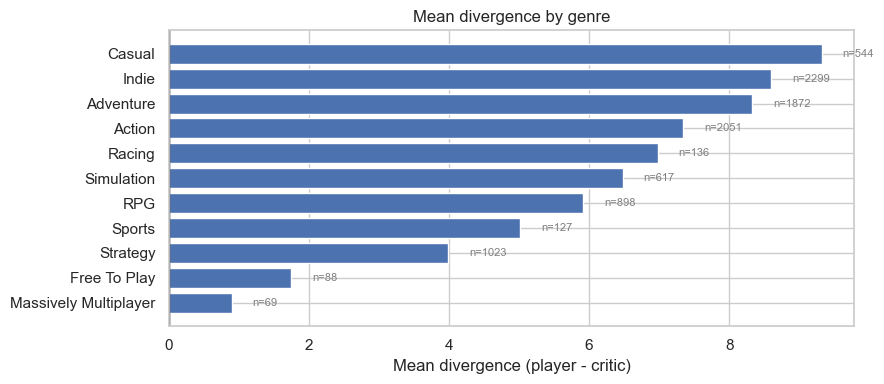

In [12]:
fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(genre_stats))))
genre_plot = genre_stats.sort_values("mean_div")
colors = ["#4C72B0" if v >= 0 else "#C44E52" for v in genre_plot["mean_div"]]
ax.barh(genre_plot["genre"], genre_plot["mean_div"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Mean divergence (player - critic)")
ax.set_title("Mean divergence by genre")
for y, (v, n) in enumerate(zip(genre_plot["mean_div"], genre_plot["n_games"])):
    ax.text(v + (0.3 if v >= 0 else -0.3), y, f"n={n}",
            va="center", ha="left" if v >= 0 else "right", fontsize=8, color="gray")
plt.tight_layout()
plt.show()

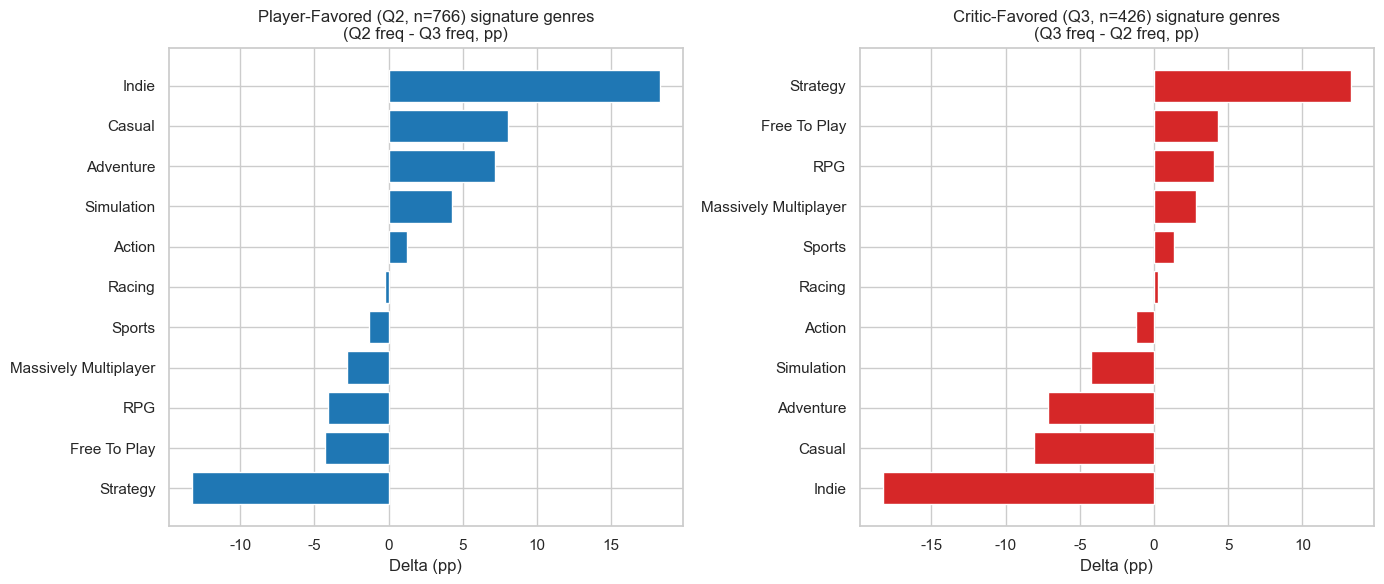

In [13]:
genre_compare = plot_quadrant_signature(genres, "genre", q2_ids, q3_ids, label="genre")

## Section 6 — Slice by category & tag

- `category` has a small cardinality, so we reuse the same mean-divergence bar chart as genre
- `tag` has a huge cardinality (thousands), so instead we compare: **tags with the biggest frequency gap between "Player-Favored (Q2)" and "Critic-Favored (Q3)"**, using a *mirrored bar chart* to surface each side's signature tags

Category slice (n_games >= 20): 37 categories kept


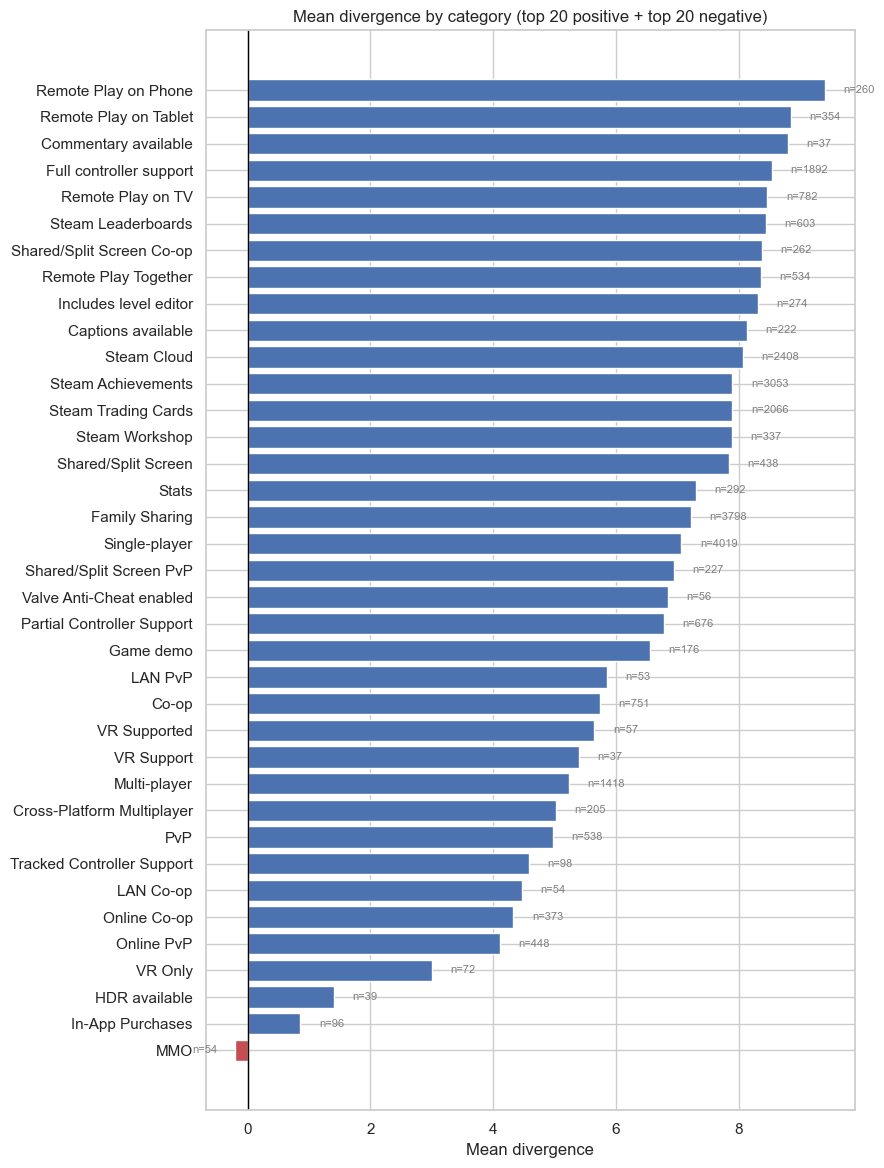

,category,n_games,mean_div,median_div,pct_Q1 Both Loved,pct_Q2 Player-Favored,pct_Q3 Critic-Favored,pct_Q4 Both Disliked
0,Remote Play on Phone,260,9.41,9.71,80.0,11.5,5.0,3.5
1,Remote Play on Tablet,354,8.85,9.31,78.0,12.1,5.1,4.8
2,Commentary available,37,8.80,9.14,67.6,18.9,8.1,5.4
3,Full controller support,1892,8.54,9.33,49.8,18.3,8.0,23.8
4,Remote Play on TV,782,8.47,9.48,49.6,17.4,7.4,25.6
5,Steam Leaderboards,603,8.44,9.25,42.1,23.5,8.6,25.7
6,Shared/Split Screen Co-op,262,8.38,9.67,51.1,19.1,6.9,22.9
7,Remote Play Together,534,8.37,9.53,49.3,20.8,8.1,21.9
8,Includes level editor,274,8.32,8.89,51.8,19.7,8.8,19.7
9,Captions available,222,8.13,9.03,43.2,20.7,6.8,29.3


In [14]:
category_stats = slice_by_long_table(categories, "category", CONFIG["min_games_per_category"])
print(f"Category slice (n_games >= {CONFIG['min_games_per_category']}): {len(category_stats)} categories kept")

top_n_cat = 20
cat_plot = pd.concat([category_stats.head(top_n_cat), category_stats.tail(top_n_cat)]).drop_duplicates()
cat_plot = cat_plot.sort_values("mean_div")

fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(cat_plot))))
colors = ["#4C72B0" if v >= 0 else "#C44E52" for v in cat_plot["mean_div"]]
ax.barh(cat_plot["category"], cat_plot["mean_div"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Mean divergence")
ax.set_title(f"Mean divergence by category (top {top_n_cat} positive + top {top_n_cat} negative)")
for y, (v, n) in enumerate(zip(cat_plot["mean_div"], cat_plot["n_games"])):
    ax.text(v + (0.3 if v >= 0 else -0.3), y, f"n={n}",
            va="center", ha="left" if v >= 0 else "right", fontsize=8, color="gray")
plt.tight_layout()
plt.show()

category_stats.head(10)

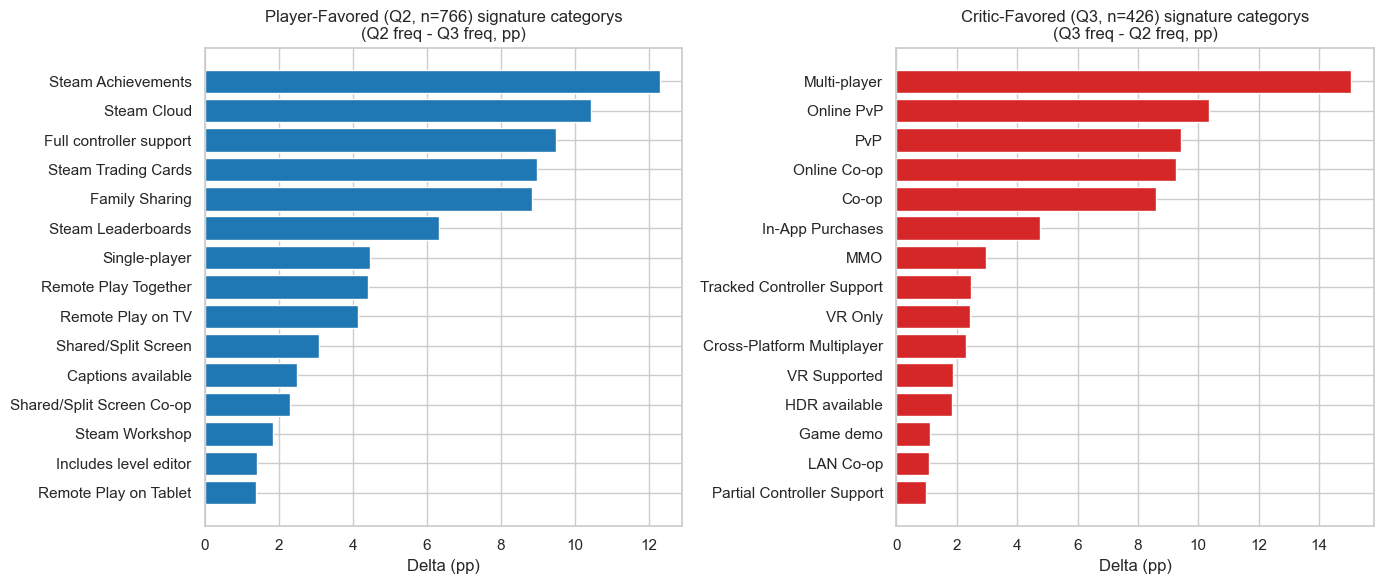

In [15]:
category_compare = plot_quadrant_signature(categories, "category", q2_ids, q3_ids, label="category")

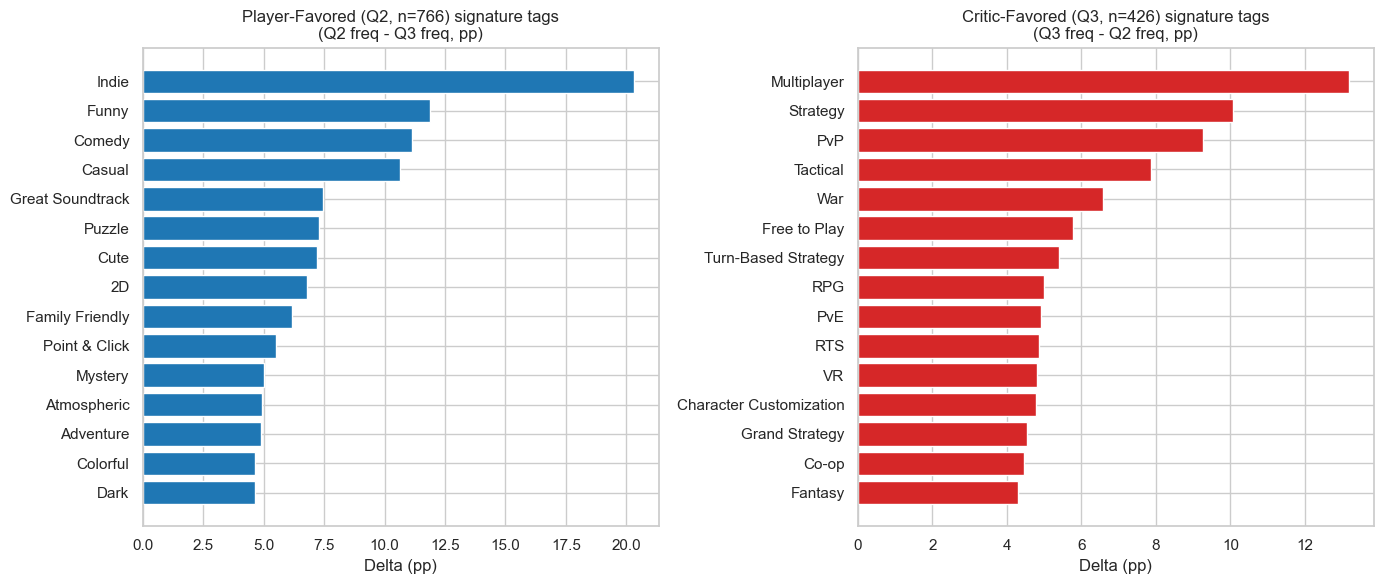

In [16]:
tag_compare = plot_quadrant_signature(tags, "tag", q2_ids, q3_ids, label="tag")

## Section 7 — Slice by publisher / developer

Which studios are systematically boosted by players (positive divergence: word-of-mouth outpaces critics), and which are systematically boosted by critics (negative divergence)?
Minimum games per entity is controlled by `min_games_per_publisher` / `min_games_per_developer`.

In [17]:
def entity_stats(col, min_games):
    sub = core[core[col].notna()]
    agg = (sub.groupby(col)
              .agg(n_games=("app_id", "nunique"),
                   mean_div=("divergence_ratio", "mean"),
                   median_div=("divergence_ratio", "median"),
                   mean_player=("player_ratio_100", "mean"),
                   mean_critic=("critic_norm", "mean"))
              .reset_index())
    agg = agg[agg["n_games"] >= min_games].copy()
    for c in ["mean_div", "median_div", "mean_player", "mean_critic"]:
        agg[c] = agg[c].round(1)
    return agg

pub_stats = entity_stats("publisher", CONFIG["min_games_per_publisher"])
dev_stats = entity_stats("developer", CONFIG["min_games_per_developer"])

print(f"Publisher candidates (n_games >= {CONFIG['min_games_per_publisher']}): {len(pub_stats)}")
print(f"Developer candidates (n_games >= {CONFIG['min_games_per_developer']}): {len(dev_stats)}")

print("\n[Publisher - most under-rated Top 15 (highest mean_div)]")
pub_top = pub_stats.nlargest(CONFIG["top_n"], "mean_div").reset_index(drop=True)
pub_top

Publisher candidates (n_games >= 5): 145
Developer candidates (n_games >= 5): 105

[Publisher - most under-rated Top 15 (highest mean_div)]


,publisher,n_games,mean_div,median_div,mean_player,mean_critic
0,Scott Cawthon,5,27.9,28.7,92.1,64.2
1,SCS Software,5,19.2,18.6,93.4,74.2
2,"XSEED Games, Marvelous USA, Inc., Marvelous",9,18.0,18.5,85.4,67.3
3,"NIS America, Inc.",6,15.9,15.6,82.9,67.0
4,Coffee Stain Publishing,7,15.5,13.0,92.9,77.4
5,Rebellion,24,15.0,16.0,82.7,67.7
6,Telltale Games,5,14.6,14.3,86.2,71.6
7,"XSEED Games, Marvelous USA, Inc.",15,14.5,14.1,91.1,76.6
8,Nightdive Studios,8,14.0,11.8,87.6,73.6
9,PLAYISM,14,13.7,13.1,84.5,70.8


In [18]:
print("[Publisher - most over-rated Top 15 (lowest mean_div)]")
pub_bot = pub_stats.nsmallest(CONFIG["top_n"], "mean_div").reset_index(drop=True)
pub_bot

[Publisher - most over-rated Top 15 (lowest mean_div)]


,publisher,n_games,mean_div,median_div,mean_player,mean_critic
0,Stardock Entertainment,12,-8.2,-5.9,72.0,80.2
1,Funbox Media Ltd,7,-6.9,-9.8,61.1,68.0
2,"Arcen Games, LLC",9,-5.7,2.7,63.1,68.8
3,Kalypso Media Digital,27,-5.2,-3.8,64.3,69.4
4,Tribute Games Inc.,5,-4.5,-5.5,72.5,77.0
5,"SEGA, Feral Interactive (Mac), Feral Interacti...",12,-3.7,-0.2,79.8,83.5
6,Microids,18,-3.6,-0.6,67.4,71.0
7,Viva Media,8,-3.4,-3.4,59.3,62.8
8,Eidos Interactive Corp.,7,-2.9,0.4,78.5,81.4
9,Nival,5,-2.7,6.0,68.5,71.2


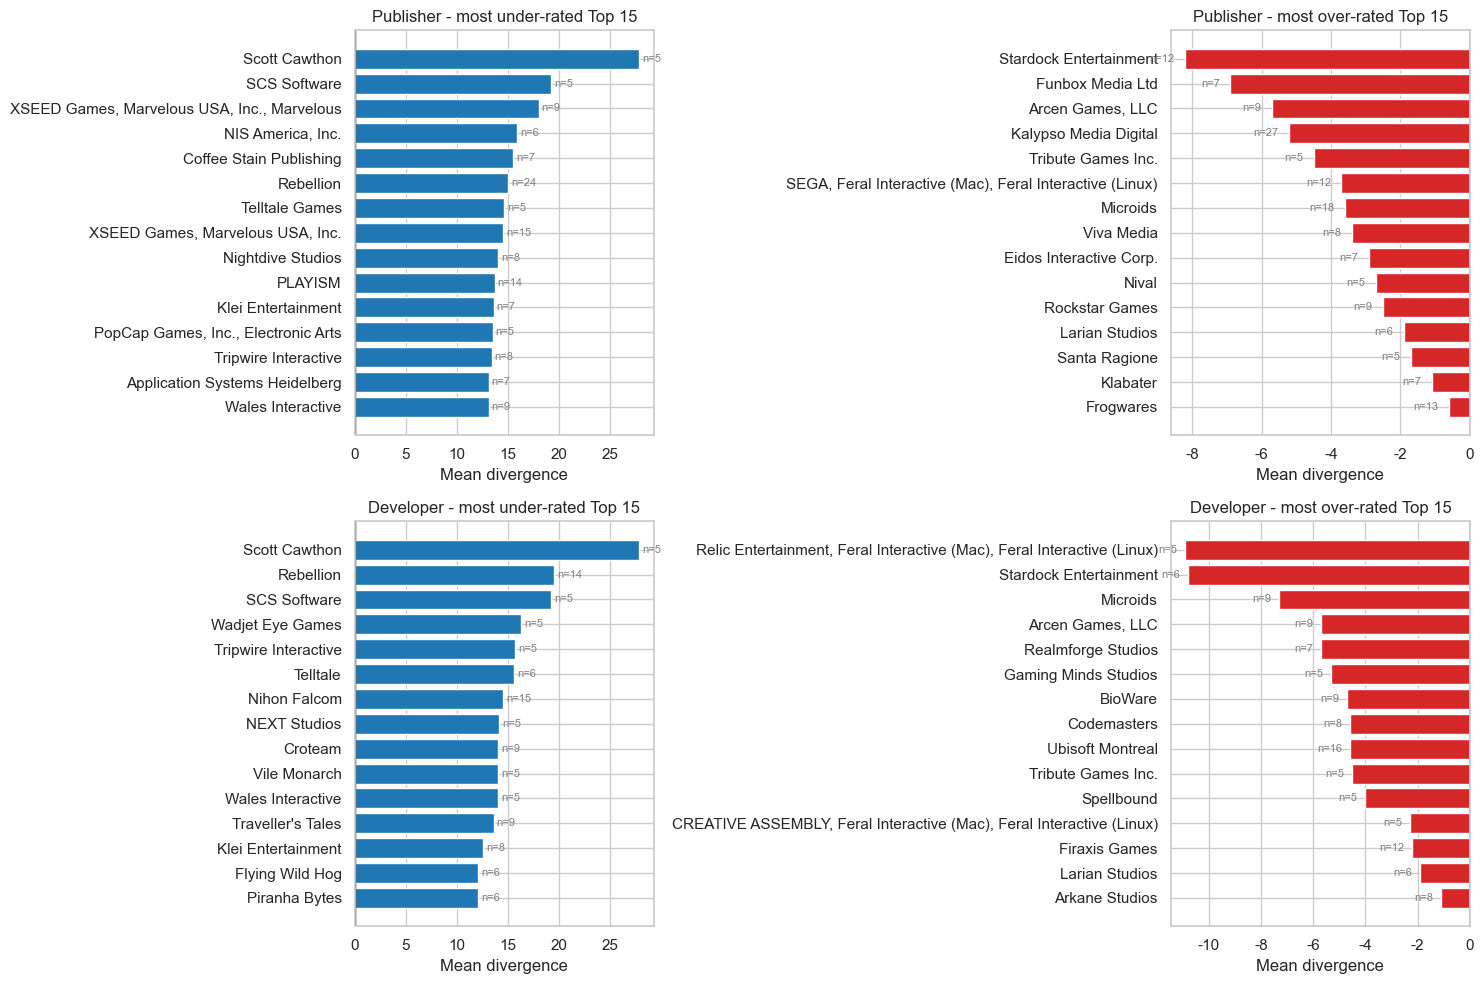

In [19]:
dev_top = dev_stats.nlargest(CONFIG["top_n"], "mean_div").reset_index(drop=True)
dev_bot = dev_stats.nsmallest(CONFIG["top_n"], "mean_div").reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, df_, title, color in [
    (axes[0, 0], pub_top.iloc[::-1], "Publisher - most under-rated Top 15", "#1f77b4"),
    (axes[0, 1], pub_bot.iloc[::-1], "Publisher - most over-rated Top 15", "#d62728"),
    (axes[1, 0], dev_top.iloc[::-1], "Developer - most under-rated Top 15", "#1f77b4"),
    (axes[1, 1], dev_bot.iloc[::-1], "Developer - most over-rated Top 15", "#d62728"),
]:
    key_col = df_.columns[0]
    ax.barh(df_[key_col], df_["mean_div"], color=color)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Mean divergence")
    for y, (v, n) in enumerate(zip(df_["mean_div"], df_["n_games"])):
        ax.text(v + (0.3 if v >= 0 else -0.3), y, f"n={n}",
                va="center", ha="left" if v >= 0 else "right", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

In [20]:
dev_top

,developer,n_games,mean_div,median_div,mean_player,mean_critic
0,Scott Cawthon,5,27.9,28.7,92.1,64.2
1,Rebellion,14,19.5,19.3,85.4,65.9
2,SCS Software,5,19.2,18.6,93.4,74.2
3,Wadjet Eye Games,5,16.3,15.3,93.5,77.2
4,Tripwire Interactive,5,15.7,16.6,90.5,74.8
5,Telltale,6,15.6,14.1,90.8,75.2
6,Nihon Falcom,15,14.5,14.2,91.7,77.2
7,NEXT Studios,5,14.1,12.6,88.7,74.6
8,Croteam,9,14.0,15.1,92.1,78.1
9,Vile Monarch,5,14.0,18.9,80.2,66.2


In [21]:
dev_bot

,developer,n_games,mean_div,median_div,mean_player,mean_critic
0,"Relic Entertainment, Feral Interactive (Mac), ...",5,-10.9,-6.1,68.7,79.6
1,Stardock Entertainment,6,-10.8,-10.2,67.5,78.3
2,Microids,9,-7.3,-3.0,64.3,71.6
3,"Arcen Games, LLC",9,-5.7,2.7,63.1,68.8
4,Realmforge Studios,7,-5.7,-11.6,62.4,68.1
5,Gaming Minds Studios,5,-5.3,-5.3,63.5,68.8
6,BioWare,9,-4.7,-3.7,80.7,85.4
7,Codemasters,8,-4.6,-6.4,72.3,76.9
8,Ubisoft Montreal,16,-4.6,-4.3,78.0,82.6
9,Tribute Games Inc.,5,-4.5,-5.5,72.5,77.0


## Section 8 — Slice by price / free vs paid / owners range

Do player-critic divergence patterns differ along commercial dimensions? Three slices:

- `price` buckets: 0 / 0-5 / 5-15 / 15-30 / 30-60 / 60+ USD
- `is_free`: free vs paid
- `owners_range`: ordered owners buckets

In [22]:
price_bins   = [-0.01, 0.001, 5, 15, 30, 60, np.inf]
price_labels = ["0 (free)", "(0, 5]", "(5, 15]", "(15, 30]", "(30, 60]", "60+"]
core["price_bucket"] = pd.cut(core["price"], bins=price_bins, labels=price_labels)

price_summary = (
    core.dropna(subset=["price_bucket"])
        .groupby("price_bucket", observed=True)["divergence_ratio"]
        .agg(["count", "mean", "median"]).round(2)
        .rename(columns={"count": "n_games", "mean": "mean_div", "median": "median_div"})
        .reset_index()
)
price_summary

,price_bucket,n_games,mean_div,median_div
0,0 (free),362,4.51,6.18
1,"(0, 5]",601,6.49,7.68
2,"(5, 15]",1601,8.03,9.34
3,"(15, 30]",1292,7.27,8.56
4,"(30, 60]",275,3.57,4.87
5,60+,11,0.46,1.94


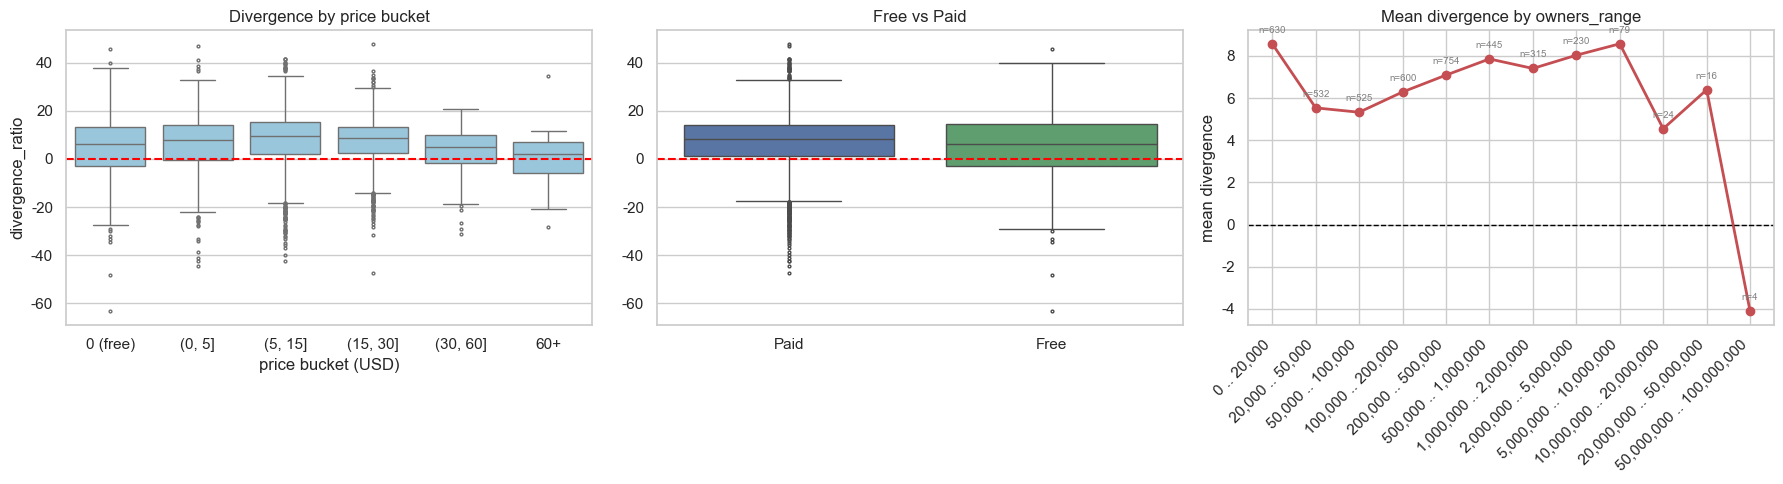


Free vs Paid divergence (mean & median):
      count  mean  median
type                     
Free    285  5.33    6.33
Paid   3870  7.05    8.29


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_df = core.dropna(subset=["price_bucket"])
sns.boxplot(data=plot_df, x="price_bucket", y="divergence_ratio",
            ax=axes[0], color="#8ecae6", fliersize=2)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Divergence by price bucket")
axes[0].set_xlabel("price bucket (USD)")
axes[0].set_ylabel("divergence_ratio")

free_df = core.dropna(subset=["is_free"]).copy()
free_df["type"] = free_df["is_free"].map({0: "Paid", 1: "Free"})
sns.boxplot(data=free_df, x="type", y="divergence_ratio",
            ax=axes[1], hue="type", palette={"Paid": "#4C72B0", "Free": "#55A868"},
            legend=False, fliersize=2)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Free vs Paid")
axes[1].set_xlabel(""); axes[1].set_ylabel("")

owners_summary = (
    core.dropna(subset=["owners_range"])
        .groupby("owners_range", observed=True)["divergence_ratio"]
        .agg(["count", "mean"]).reset_index()
        .rename(columns={"count": "n_games", "mean": "mean_div"})
)
owners_summary = owners_summary.sort_values("owners_range")

axes[2].plot(range(len(owners_summary)), owners_summary["mean_div"],
             marker="o", color="#C44E52", linewidth=2)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_xticks(range(len(owners_summary)))
axes[2].set_xticklabels(owners_summary["owners_range"].astype(str), rotation=45, ha="right")
axes[2].set_title("Mean divergence by owners_range")
axes[2].set_ylabel("mean divergence")

for i, n in enumerate(owners_summary["n_games"]):
    axes[2].annotate(f"n={n}",
                     xy=(i, owners_summary["mean_div"].iloc[i]),
                     xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=7, color="gray")

plt.tight_layout()
plt.show()

print("\nFree vs Paid divergence (mean & median):")
print(free_df.groupby("type")["divergence_ratio"].agg(["count", "mean", "median"]).round(2))

## Section 9 — Trend by release year

Does the player-critic divergence shift over time? We overlay sample-size bars so years with fewer than ~10 samples can be read with appropriate caution.

C:\Users\willi\AppData\Local\Temp\ipykernel_31968\139495702.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  year_stats = (year_df.groupby("release_year").apply(agg_year).reset_index())


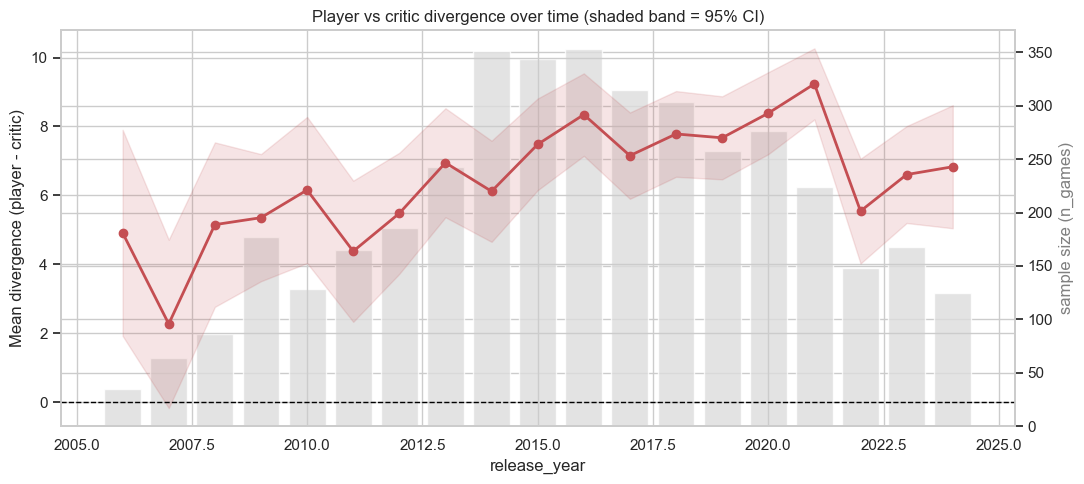

,release_year,n_games,mean_div,sem,ci95
7,2006,35.0,4.91,1.53,2.99
8,2007,64.0,2.27,1.25,2.44
9,2008,86.0,5.15,1.22,2.39
10,2009,177.0,5.35,0.94,1.84
11,2010,128.0,6.16,1.08,2.12
12,2011,165.0,4.38,1.05,2.05
13,2012,186.0,5.48,0.90,1.76
14,2013,243.0,6.95,0.81,1.58
15,2014,351.0,6.12,0.75,1.47
16,2015,344.0,7.48,0.68,1.33


In [24]:
year_df = core.dropna(subset=["release_year"]).copy()
year_df["release_year"] = year_df["release_year"].astype(int)

def agg_year(g):
    n = len(g)
    mean = g["divergence_ratio"].mean()
    sem  = g["divergence_ratio"].std(ddof=1) / np.sqrt(n) if n > 1 else np.nan
    return pd.Series({"n_games": n, "mean_div": mean, "sem": sem})

year_stats = (year_df.groupby("release_year").apply(agg_year).reset_index())
year_stats = year_stats[year_stats["n_games"] >= 5]
year_stats["ci95"] = 1.96 * year_stats["sem"]

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax2.bar(year_stats["release_year"], year_stats["n_games"],
        color="#dddddd", alpha=0.8, label="sample size")
ax2.set_ylabel("sample size (n_games)", color="gray")

ax1.fill_between(
    year_stats["release_year"],
    year_stats["mean_div"] - year_stats["ci95"],
    year_stats["mean_div"] + year_stats["ci95"],
    color="#C44E52", alpha=0.15,
)
ax1.plot(year_stats["release_year"], year_stats["mean_div"],
         color="#C44E52", linewidth=2, marker="o", label="mean divergence")
ax1.axhline(0, color="black", linestyle="--", linewidth=1)
ax1.set_ylabel("Mean divergence (player - critic)")
ax1.set_xlabel("release_year")
ax1.set_title("Player vs critic divergence over time (shaded band = 95% CI)")

ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

plt.tight_layout()
plt.show()

year_stats.round(2)